# Chương 3 — So sánh CNN scratch, Keras và PyTorch

Notebook này đọc lại artifact đã được tạo bởi Phase 4. Notebook **không huấn luyện lại** và không chọn mô hình từ TEST. Mục tiêu là kiểm tra split/provenance, tái tính metric từ prediction CSV, trình bày kết quả matched trên EuroSAT và CDC Diabetes, sau đó đặt kết quả A05 full-data ở một bảng ablation riêng.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

start = Path.cwd().resolve()
ROOT = next(path for path in (start, *start.parents) if (path / "term_paper").exists())
TERM = ROOT / "term_paper"
METRICS = TERM / "artifacts" / "metrics"
PREDICTIONS = TERM / "artifacts" / "predictions"
FIGURES = TERM / "artifacts" / "figures" / "ch3"
MANIFESTS = TERM / "artifacts" / "manifests" / "ch3"
print("Workspace:", ROOT)

Workspace: C:\DATA\assign


## 1. Protocol và benchmark subset

- EuroSAT: 500 TRAIN / 150 VALIDATION / 150 TEST, ảnh RGB 64×64×3.
- CDC Diabetes 012: 6.000 / 1.500 / 1.500, 21 feature chuẩn hóa theo TRAIN và reshape `(21,1)`.
- Topology: Conv(8, kernel 3) → ReLU → MaxPool(2) → Conv(16, kernel 3) → ReLU → Global Average Pooling → Dense logits.
- Learning-rate candidates: 0,01 và 0,003; chọn bằng VALIDATION macro-F1.
- Model seeds: 42, 52 và 62; subset seed luôn là 42.

In [2]:
dataset_summary = pd.read_csv(METRICS / "ch3_dataset_summary.csv")
display(dataset_summary)
for dataset in ("ch3_eurosat", "ch3_diabetes_012"):
    metadata = json.loads((MANIFESTS / f"{dataset}_metadata.json").read_text(encoding="utf-8"))
    print(dataset, "split hash:", metadata["split_sha256"])
    print("class distribution:", metadata["class_distribution"])

,dataset_id,full_samples,classes,input,matched_train,matched_val,matched_test,role
0,ch3_eurosat,27000,10,64×64×3 RGB,500.0,150.0,150.0,matched + A05 full-data ablation
1,ch3_oxford_pets,7349,37,RGB resized 96×96,NaN,NaN,NaN,A05 Keras case study
2,ch3_diabetes_012,253680,3,21×1 standardized features,6000.0,1500.0,1500.0,matched + A05 full-data ablation


ch3_eurosat split hash: 2d793bd925697e553c22ab7ed06a7732e14f7a96943309ce5ef161b7807c6ce1
class distribution: {'train': {'0': 56, '1': 56, '2': 56, '3': 46, '4': 46, '5': 37, '6': 46, '7': 55, '8': 46, '9': 56}, 'val': {'0': 17, '1': 16, '2': 17, '3': 14, '4': 14, '5': 11, '6': 14, '7': 17, '8': 14, '9': 16}, 'test': {'0': 17, '1': 17, '2': 17, '3': 14, '4': 14, '5': 11, '6': 14, '7': 16, '8': 14, '9': 16}}
ch3_diabetes_012 split hash: c9446f43c942968f585d253e6483633315625aa9938539b80645ab6cf8084075
class distribution: {'train': {'0': 5054, '1': 110, '2': 836}, 'val': {'0': 1264, '1': 27, '2': 209}, 'test': {'0': 1264, '1': 27, '2': 209}}


## 2. Phân bố ba dataset

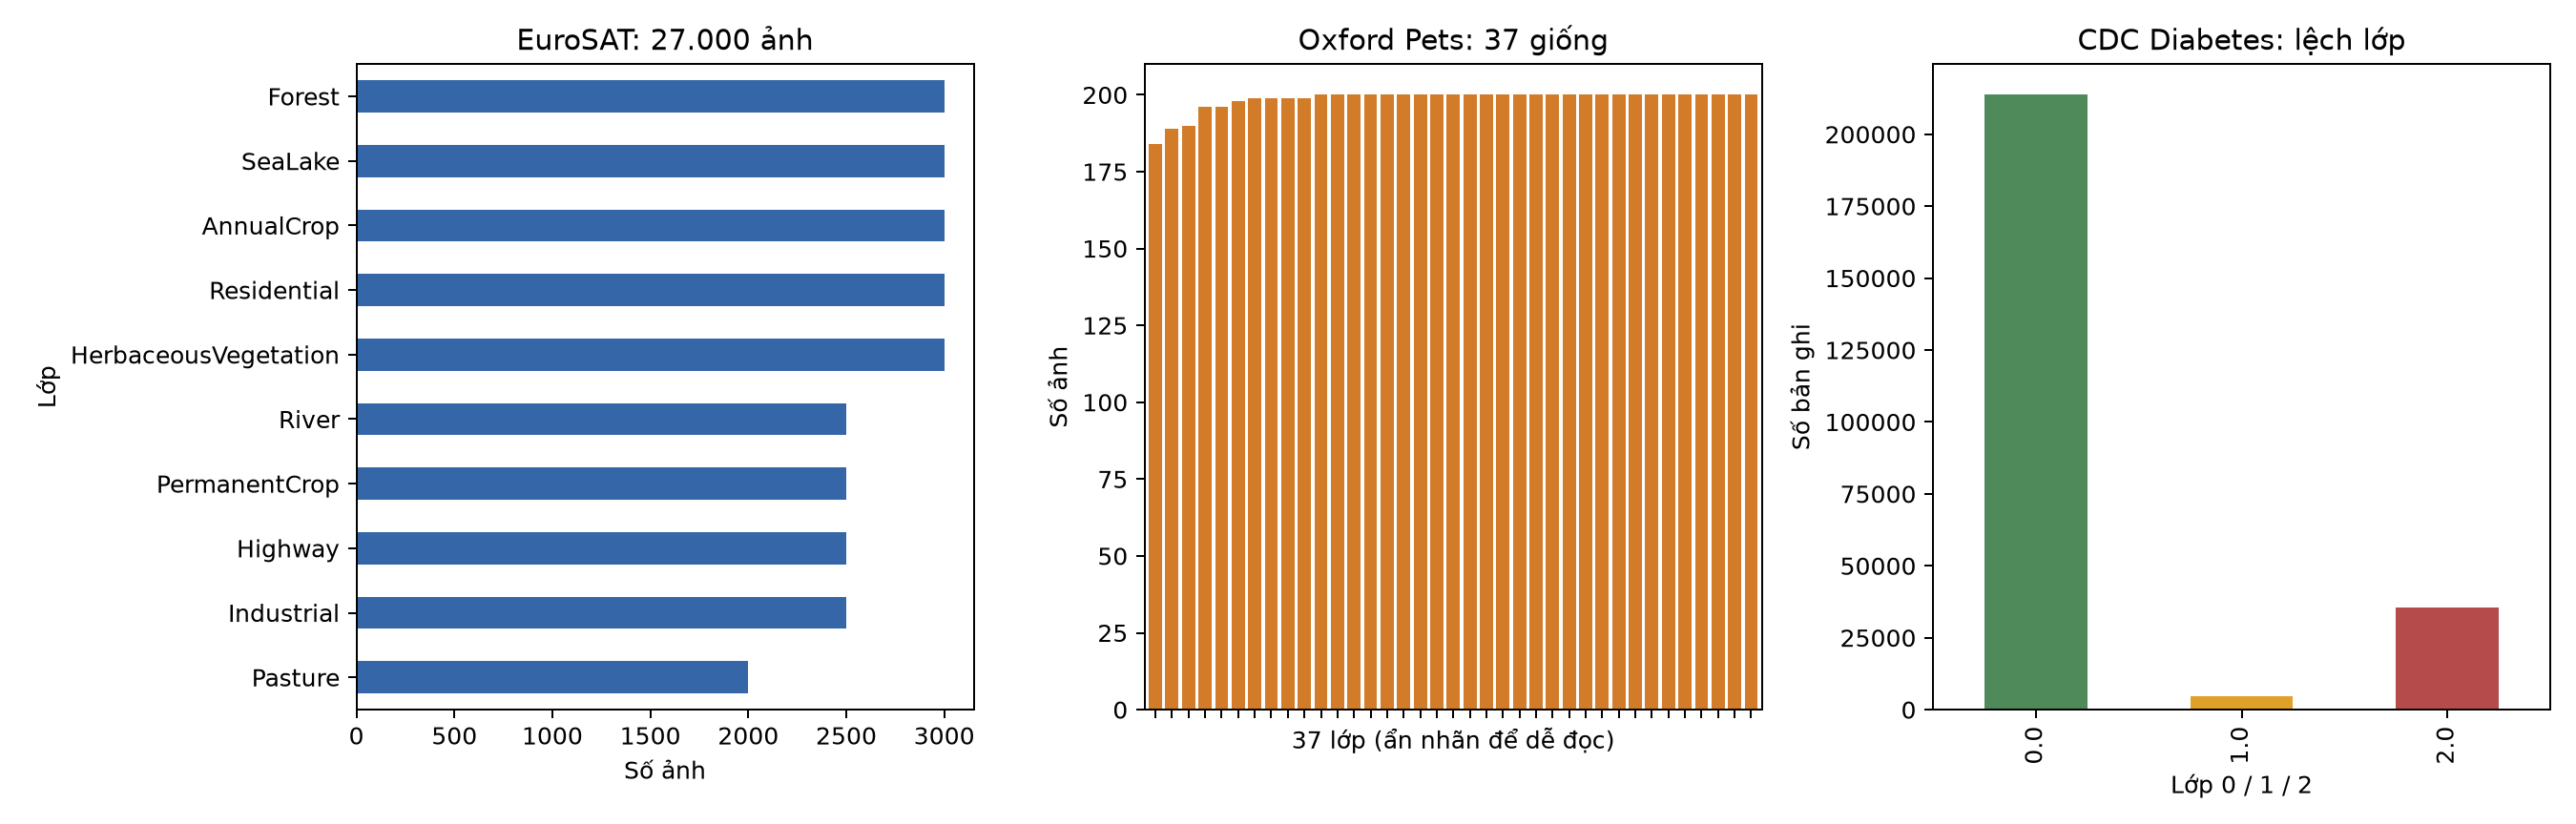

In [3]:
display(Image(filename=str(FIGURES / "ch3_dataset_distributions.png")))

EuroSAT gần cân bằng nhưng Pasture ít hơn các lớp 3.000 ảnh. Oxford có 37 lớp gần cân bằng. CDC lệch mạnh: Prediabetes chỉ chiếm khoảng 1,83%, vì vậy accuracy không thể thay thế macro-F1 và recall theo lớp.

## 3. Tái tính metric từ prediction artifact

In [4]:
comparison = pd.read_csv(METRICS / "ch3_framework_comparison.csv")
checks = []
for _, row in comparison.iterrows():
    prediction = pd.read_csv(TERM / row["prediction_path"])
    labels = sorted(prediction["y_true"].unique())
    precision, recall, f1, _ = precision_recall_fscore_support(
        prediction["y_true"], prediction["y_pred"], labels=labels,
        average="macro", zero_division=0
    )
    accuracy = accuracy_score(prediction["y_true"], prediction["y_pred"])
    checks.append({
        "dataset": row["dataset_id"], "framework": row["framework"], "seed": row["seed"],
        "accuracy_delta": abs(accuracy - row["accuracy"]),
        "macro_f1_delta": abs(f1 - row["macro_f1"]),
        "samples": len(prediction),
    })
checks = pd.DataFrame(checks)
display(checks.head(9))
assert checks[["accuracy_delta", "macro_f1_delta"]].to_numpy().max() < 1e-12
print("PASS: metric của 18 run tái tính khớp CSV tổng hợp.")

,dataset,framework,seed,accuracy_delta,macro_f1_delta,samples
0,ch3_diabetes_012,keras,42,0.0,5.551115e-17,1500
1,ch3_diabetes_012,keras,52,0.0,0.000000e+00,1500
2,ch3_diabetes_012,keras,62,0.0,0.000000e+00,1500
3,ch3_diabetes_012,numpy,42,0.0,5.551115e-17,1500
4,ch3_diabetes_012,numpy,52,0.0,0.000000e+00,1500
5,ch3_diabetes_012,numpy,62,0.0,0.000000e+00,1500
6,ch3_diabetes_012,pytorch,42,0.0,0.000000e+00,1500
7,ch3_diabetes_012,pytorch,52,0.0,5.551115e-17,1500
8,ch3_diabetes_012,pytorch,62,0.0,5.551115e-17,1500


PASS: metric của 18 run tái tính khớp CSV tổng hợp.


## 4. Sample-key parity giữa ba framework

In [5]:
for dataset in comparison["dataset_id"].unique():
    for seed in sorted(comparison["seed"].unique()):
        selected = comparison[(comparison.dataset_id == dataset) & (comparison.seed == seed)]
        keys = []
        for _, row in selected.iterrows():
            frame = pd.read_csv(TERM / row["prediction_path"])
            keys.append(frame[["sample_key", "y_true"]].astype(str).reset_index(drop=True))
        assert len(keys) == 3 and keys[0].equals(keys[1]) and keys[0].equals(keys[2])
print("PASS: cùng TEST sample và target cho mọi dataset/seed/framework.")

PASS: cùng TEST sample và target cho mọi dataset/seed/framework.


## 5. Kết quả matched trên ba seed

,dataset_id,framework,run_count,parameter_count,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,recall_class_1_mean,recall_class_2_mean,training_seconds_mean,inference_ms_per_sample_mean
0,ch3_diabetes_012,keras,3,483,0.684667,0.023333,0.411856,0.016126,0.123457,0.527911,2.171167,0.031436
1,ch3_diabetes_012,numpy,3,483,0.719556,0.041922,0.407456,0.019143,0.037037,0.496013,0.894962,0.004113
2,ch3_diabetes_012,pytorch,3,483,0.729333,0.030383,0.415342,0.005322,0.061728,0.484848,0.442916,0.001465
3,ch3_eurosat,keras,3,1562,0.333333,0.064291,0.264133,0.079417,0.588235,0.117647,1.817797,0.360459
4,ch3_eurosat,numpy,3,1562,0.324444,0.066778,0.240331,0.066642,0.294118,0.274510,42.508966,1.248773
5,ch3_eurosat,pytorch,3,1562,0.293333,0.024037,0.202565,0.009767,0.784314,0.098039,1.197778,0.028293


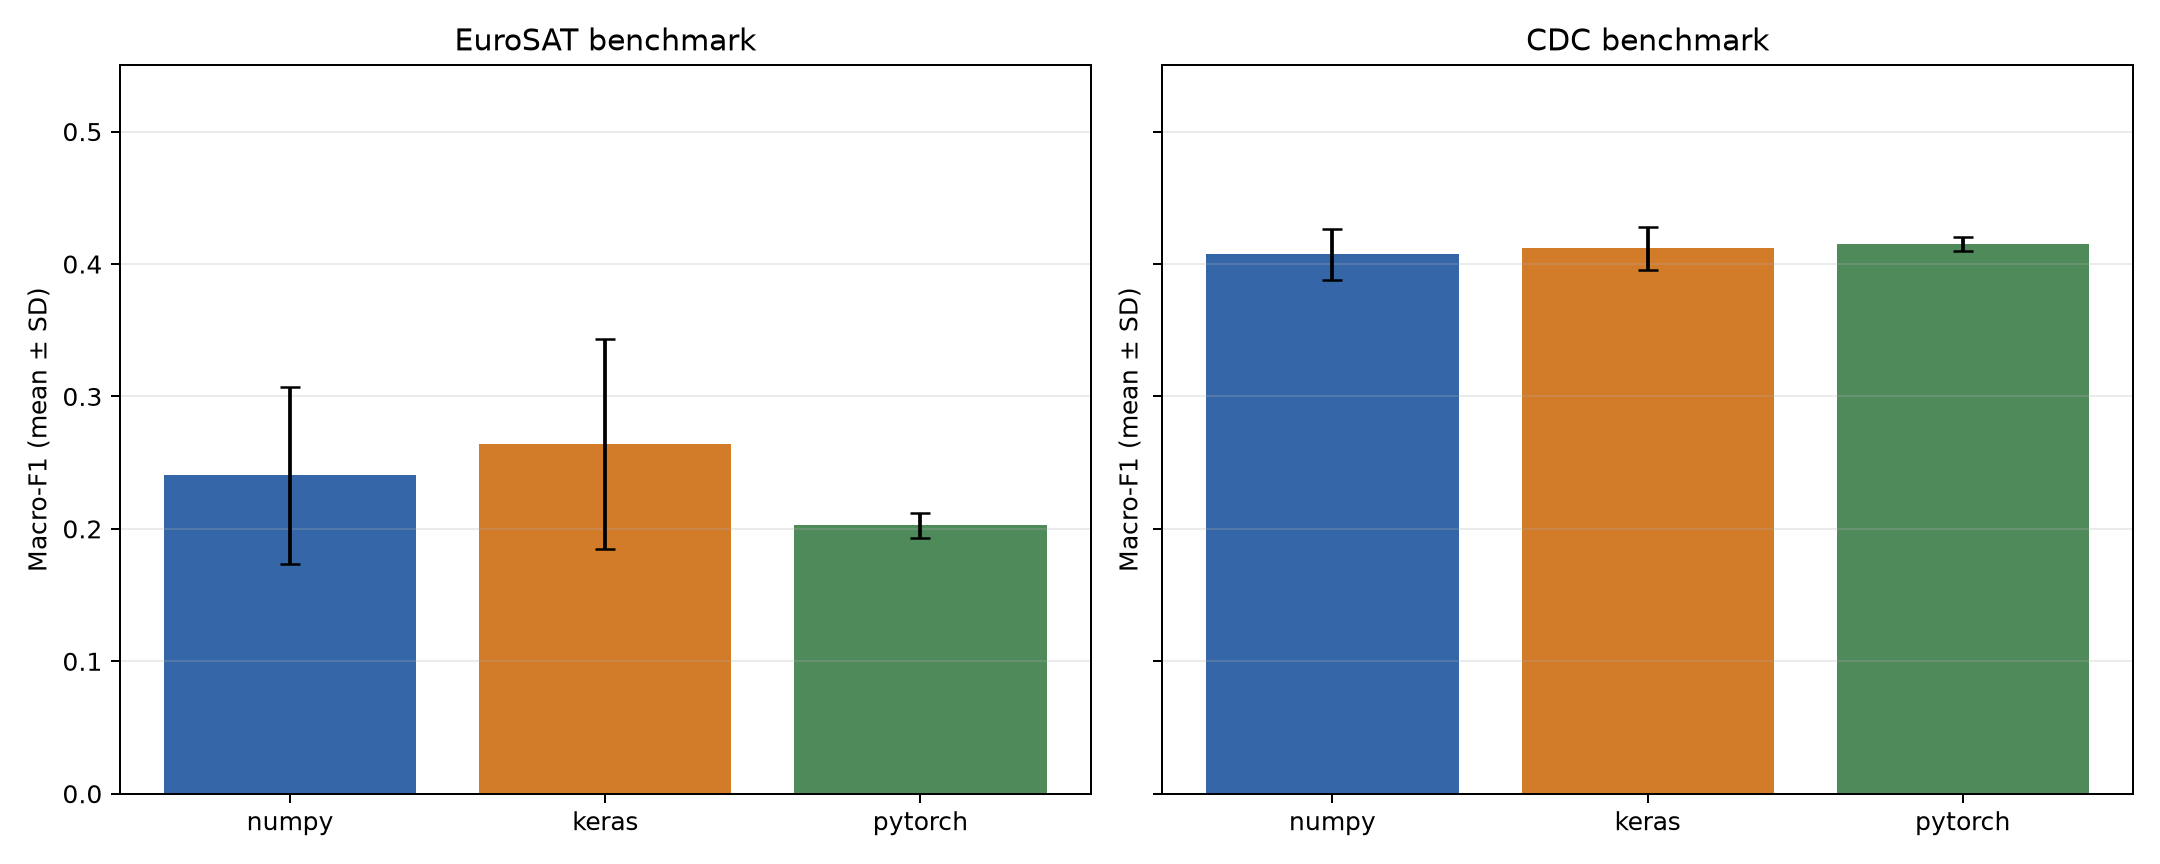

In [6]:
summary = pd.read_csv(METRICS / "ch3_framework_summary.csv")
columns = [
    "dataset_id", "framework", "run_count", "parameter_count",
    "accuracy_mean", "accuracy_std", "macro_f1_mean", "macro_f1_std",
    "recall_class_1_mean", "recall_class_2_mean",
    "training_seconds_mean", "inference_ms_per_sample_mean",
]
display(summary[[column for column in columns if column in summary]])
display(Image(filename=str(FIGURES / "ch3_matched_macro_f1.png")))

Keras có mean macro-F1 EuroSAT cao nhất nhưng biến động seed lớn. Trên CDC, ba framework chỉ lệch nhau dưới 0,008 macro-F1; PyTorch cao nhất theo mean nhưng không đủ cơ sở để tuyên bố ưu thế phổ quát. Parameter count bằng nhau tuyệt đối: 1.562 cho EuroSAT và 483 cho CDC.

## 6. Learning dynamics và confusion matrix

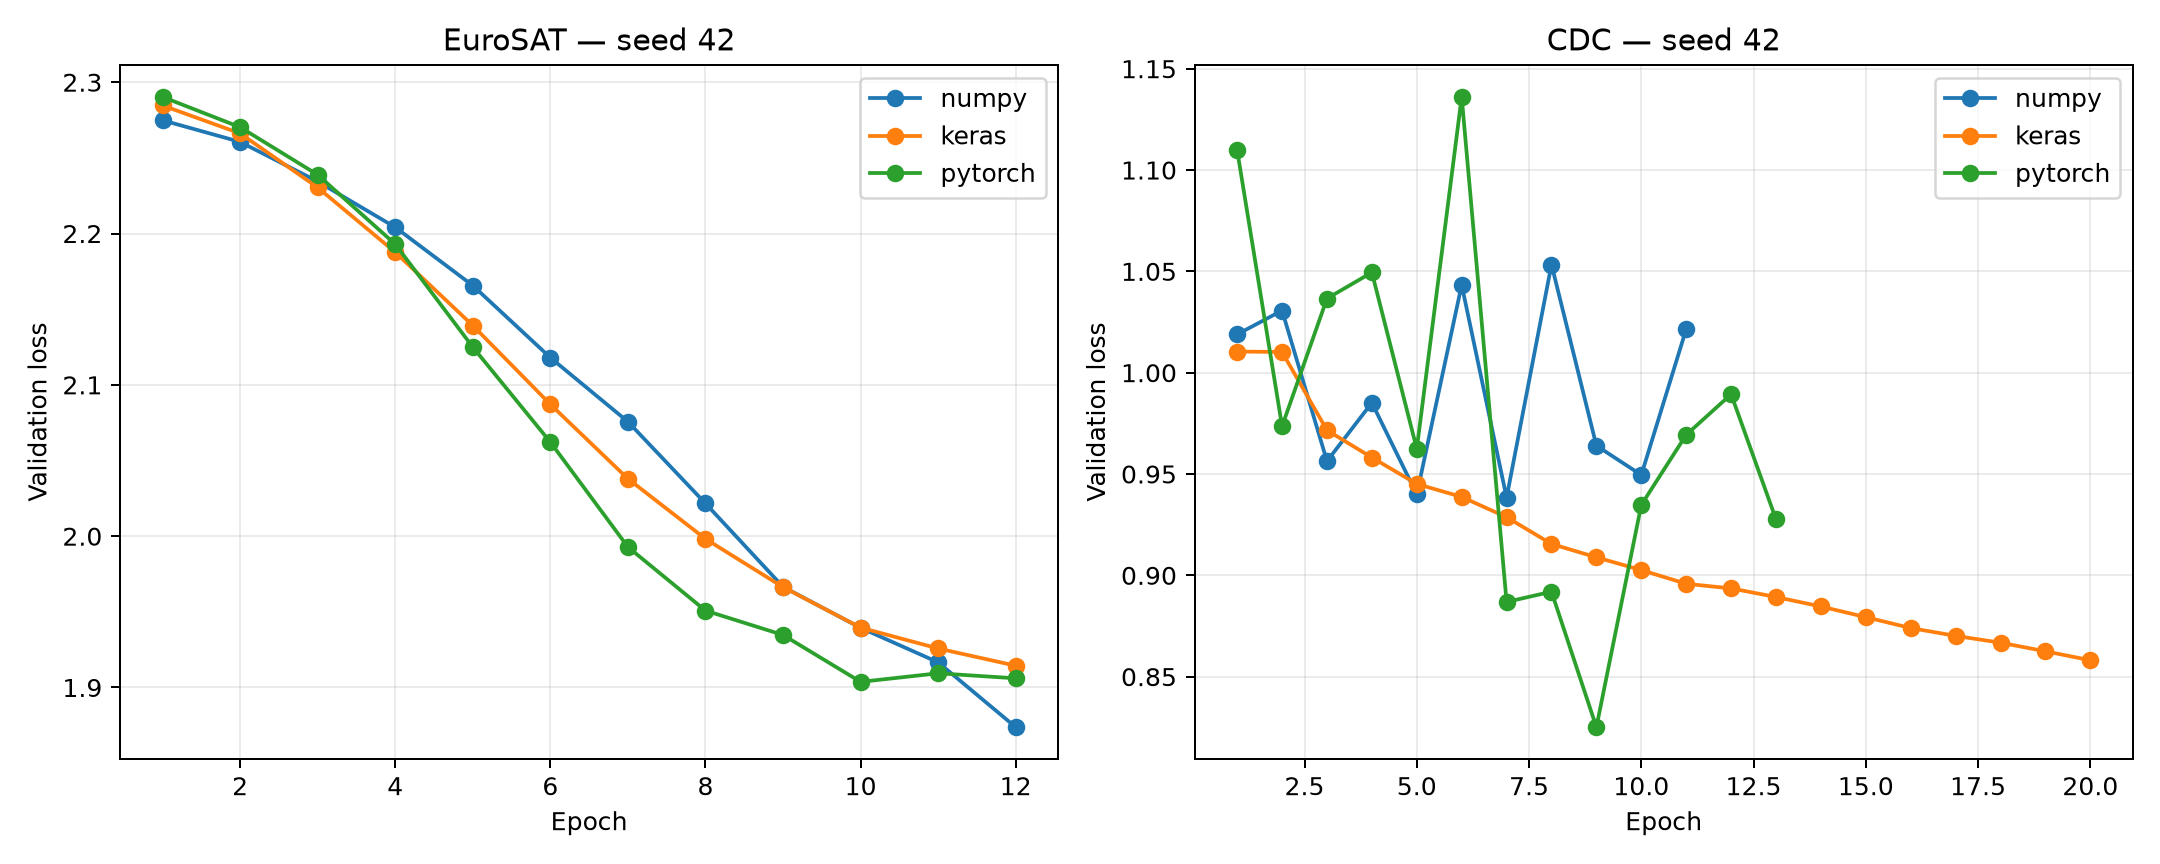

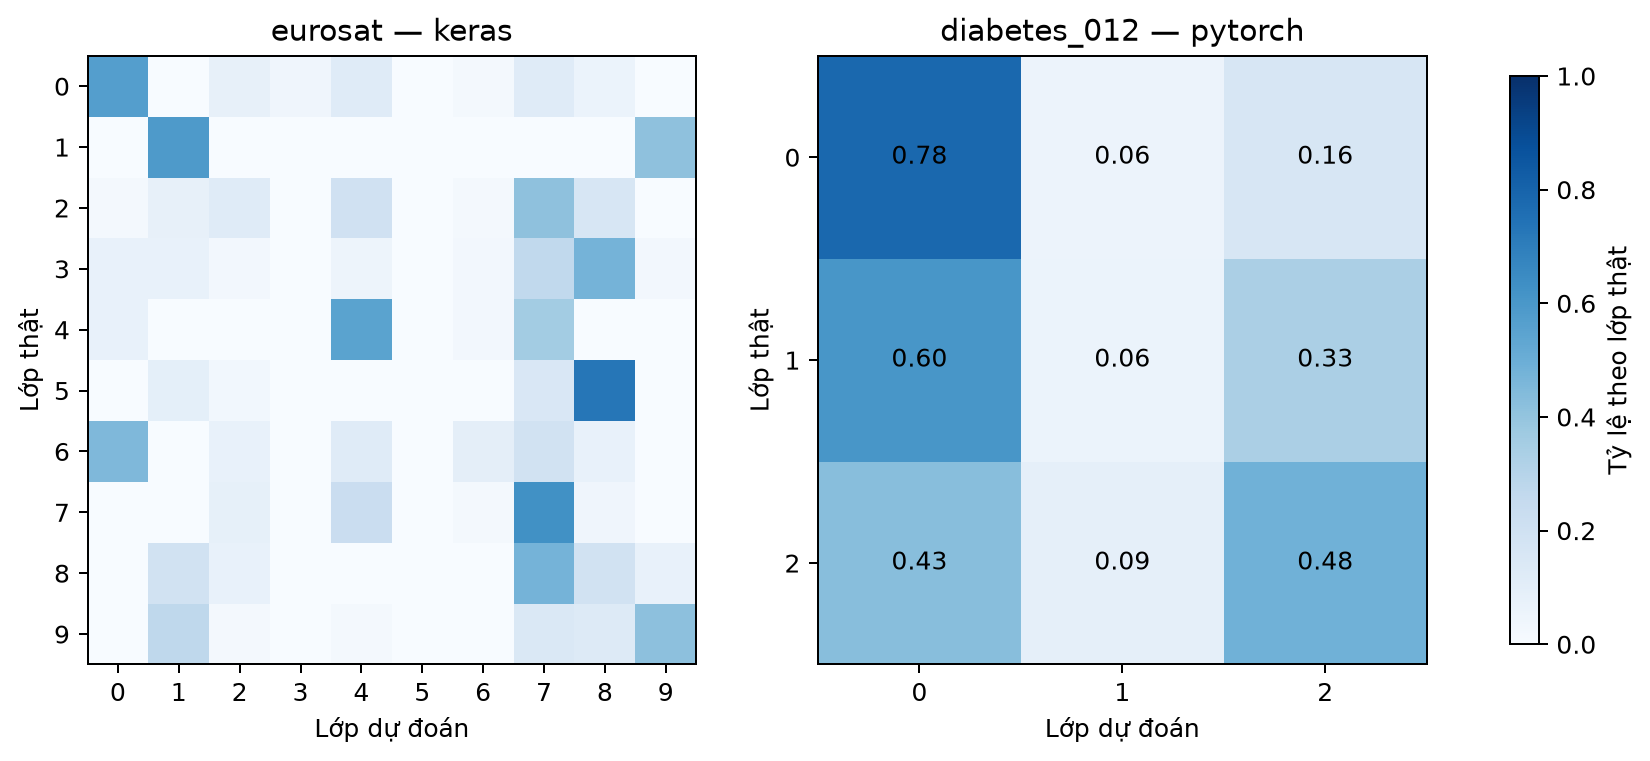

In [7]:
display(Image(filename=str(FIGURES / "ch3_validation_loss_curves.png")))
display(Image(filename=str(FIGURES / "ch3_matched_confusion_matrices.png")))

CDC Prediabetes vẫn là failure case chính dù dùng class weighting. Confusion matrix gộp ba seed cho thấy phần lớn lớp 1 bị dự đoán thành No diabetes hoặc Diabetes. Với EuroSAT subset, lỗi phân tán trên nhiều lớp và độ nhạy seed lớn hơn.

## 7. A05 architecture ablation và Oxford case study

,dataset_id,model_family,macro_f1,test_accuracy,parameter_count,training_seconds
0,a05_eurosat,BasicCNN2D,0.725624,0.739753,24202,365.389023
1,a05_eurosat,AlexNetInspired2D,0.020000,0.111111,260170,677.584922
2,a05_eurosat,VGGInspired2D,0.020000,0.111111,304810,1071.420659
3,a05_eurosat,ResNetInspired2D,0.020000,0.111111,324490,1467.592041
4,a05_oxford_pets,BasicCNN2D,0.019787,0.047152,25957,20.747897
5,a05_oxford_pets,AlexNetInspired2D,0.011541,0.040883,263653,36.932364
6,a05_oxford_pets,VGGInspired2D,0.001434,0.027255,308293,70.055179
7,a05_oxford_pets,ResNetInspired2D,0.008012,0.043336,327973,95.512476
8,a05_diabetes,BasicCNN1D,0.439204,0.695285,2787,6.467587
9,a05_diabetes,AlexNetInspired1D,0.407489,0.607984,29635,12.364384


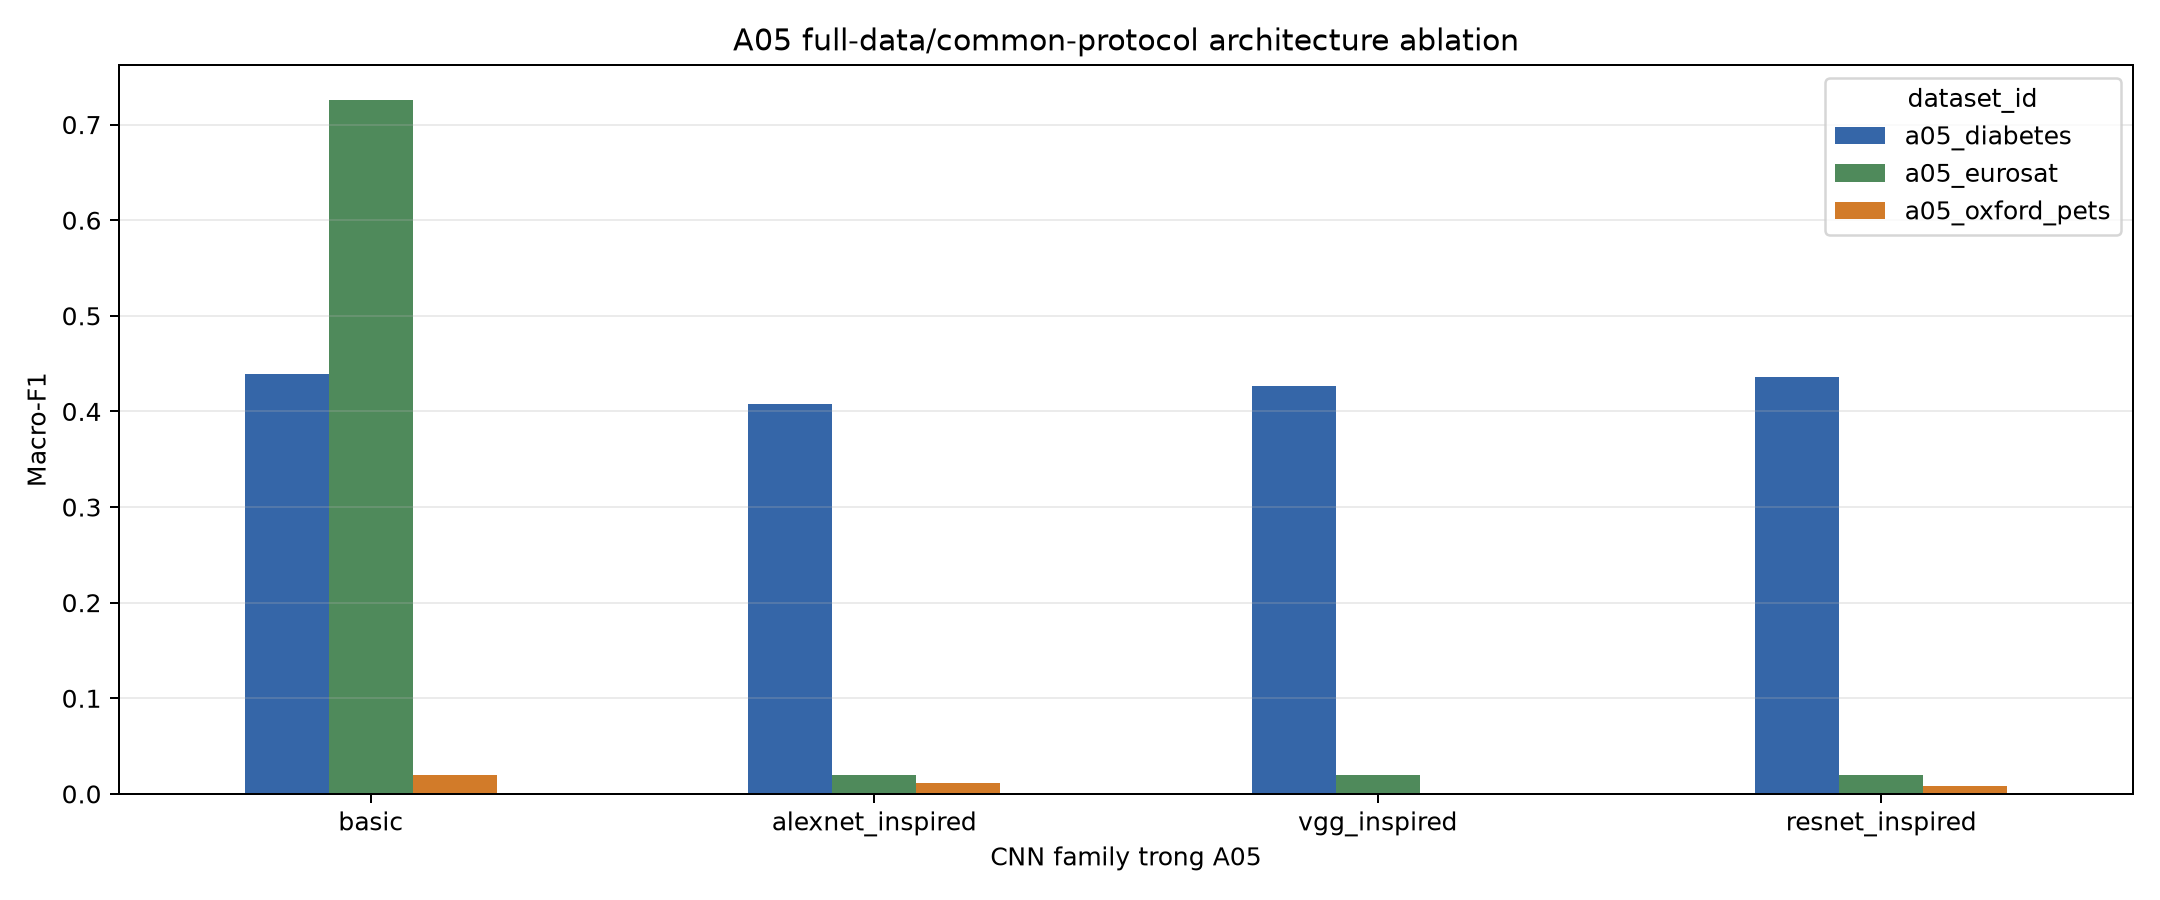

In [8]:
ablation = pd.read_csv(METRICS / "ch3_a05_architecture_ablation.csv")
display(ablation[["dataset_id", "model_family", "macro_f1", "test_accuracy", "parameter_count", "training_seconds"]])
display(Image(filename=str(FIGURES / "ch3_a05_architecture_ablation.png")))

Basic CNN đạt macro-F1 0,7256 trên EuroSAT full data. AlexNet/VGG/ResNet-inspired đều collapse ở 0,0200 dưới common protocol. Oxford rất yếu ở cả bốn family; Basic cao nhất cũng chỉ 0,0198 macro-F1. Các kết quả này được giữ nguyên như bằng chứng về giới hạn optimizer/budget, không bị loại khỏi báo cáo.

## 8. Kết luận kiểm chứng

1. Scratch CNN có backward thực cho Conv2D/Conv1D, pooling, GAP và Dense; numerical-gradient/toy-overfit được kiểm tra bằng unit test.
2. Ba framework dùng cùng benchmark samples, topology và validation search space trên EuroSAT/CDC.
3. Matched metric được tái tính từ 18 prediction files; sample-key parity đạt.
4. Oxford và architecture ablation được giữ ở track A05 riêng, không trộn với bảng matched subset.
5. Kết quả collapse/near-random được trình bày đầy đủ và giới hạn suy diễn được nêu rõ.